In [ ]:
import pandas as pd
import os
os.environ['USE_PYGEOS'] = '0'
import geopandas as gpd
from shapely.geometry import Point

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import sys
sys.path.append('..')
from helpers import get_rooftop_pv_cf_profiles_by_sector

In [9]:
retail_sales = pd.read_csv(
    '../data/county_ftm_sales_estimates.csv',
    index_col=['FIPS']
)
retail_sales.columns = [int(col) for col in retail_sales.columns]

direct_use = pd.read_csv('../data/county_direct_use.csv', index_col=['FIPS', 'is_pv'])
direct_use.columns = [int(col) for col in direct_use.columns]
direct_use = direct_use.groupby(direct_use.index.get_level_values('FIPS')).sum()

In [12]:
les = pd.read_csv(
    "../data/baseline_load_profiles/processed/LES.csv",
    parse_dates=["timestamp"],
    index_col="timestamp"
)
les = les.loc[les.index.year == 2023].copy()

nppd = pd.read_csv(
    "../data/baseline_load_profiles/processed/NPPD.csv",
    parse_dates=["timestamp"],
    index_col="timestamp"
)
nppd = nppd.loc[nppd.index.year == 2023].copy()

retail_sales_and_direct_use = retail_sales.loc['p31109', 2023] + direct_use.loc['p31109', 2023]

les_scaled = les / les.sum() * 0.814 * retail_sales_and_direct_use
nppd_scaled = nppd / nppd.sum() * 0.186 * retail_sales_and_direct_use

rsdu_profile = les_scaled + nppd_scaled

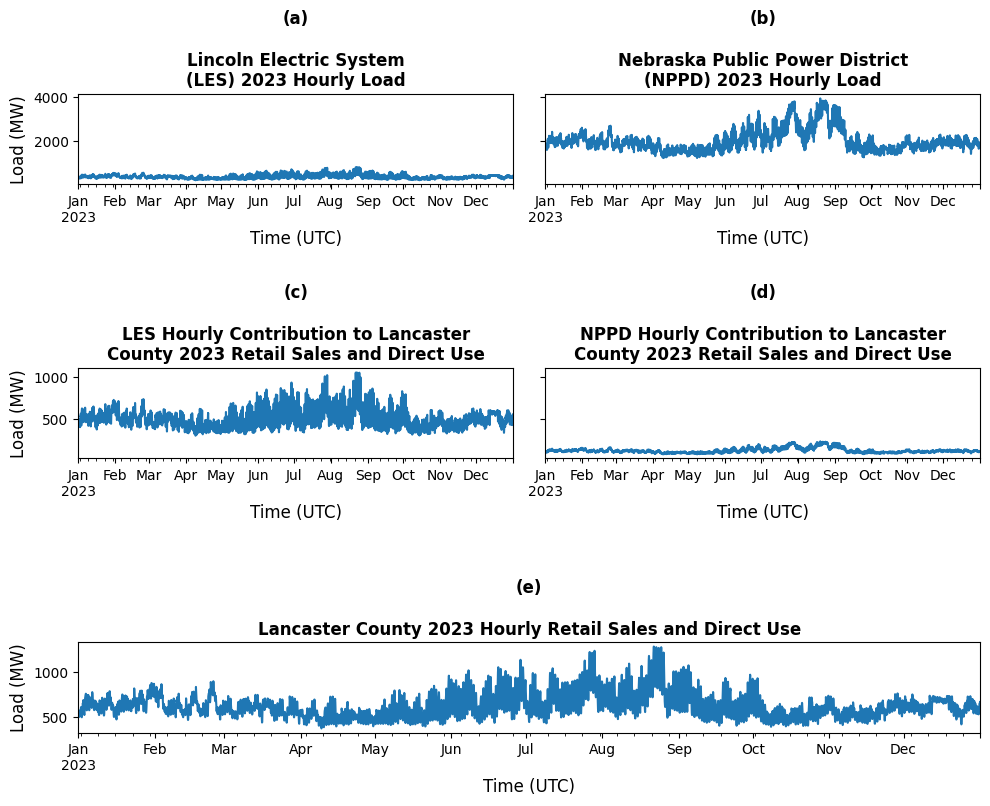

In [13]:
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(4, 2, height_ratios=[1, 1, 1, 0.7])

axes = []
for i in range(4):
    row = i // 2
    col = i % 2
    if col == 1:
        ax = fig.add_subplot(gs[row, col], sharey=axes[i-1])
    else:
        ax = fig.add_subplot(gs[row, col])
    axes.append(ax)

# Sixth plot spans the entire bottom row
ax5 = fig.add_subplot(gs[2, :])
axes.append(ax5)

ax_ = axes[0]
les.plot(ax=ax_, legend=False)
ax_.set_title('(a)\n\nLincoln Electric System\n(LES) 2023 Hourly Load', fontweight='bold')
ax_.set_xlabel('Time (UTC)', fontsize=12)
ax_.set_ylabel('Load (MW)', fontsize=12)

ax_ = axes[1]
nppd.plot(ax=ax_, legend=False)
ax_.set_title('(b)\n\nNebraska Public Power District\n(NPPD) 2023 Hourly Load', fontweight='bold')
ax_.set_xlabel('Time (UTC)', fontsize=12)

ax_ = axes[2]
les_scaled.plot(ax=ax_, legend=False)
ax_.set_title('\n(c)\n\nLES Hourly Contribution to Lancaster\nCounty 2023 Retail Sales and Direct Use', fontweight='bold')
ax_.set_xlabel('Time (UTC)', fontsize=12)
ax_.set_ylabel('Load (MW)', fontsize=12)

ax_ = axes[3]
nppd_scaled.plot(ax=ax_, legend=False)
ax_.set_title('\n(d)\n\nNPPD Hourly Contribution to Lancaster\nCounty 2023 Retail Sales and Direct Use', fontweight='bold')
ax_.set_xlabel('Time (UTC)', fontsize=12)

ax_ = axes[4]
rsdu_profile.plot(ax=ax_, legend=False)
ax_.set_title('(e)\n\nLancaster County 2023 Hourly Retail Sales and Direct Use', fontweight='bold')
ax_.set_xlabel('Time (UTC)', fontsize=12)
ax_.set_ylabel('Load (MW)', fontsize=12)

plt.tight_layout()
# plt.show()
plt.savefig('lancaster_county_rsdu_profiles.png', dpi=300, bbox_inches='tight')

In [ ]:
rooftop_pv_cf_profiles_by_sector = get_rooftop_pv_cf_profiles_by_sector()

residential_profiles = rooftop_pv_cf_profiles_by_sector['residential']
non_residential_profiles = rooftop_pv_cf_profiles_by_sector['commercial']

In [5]:
distpv_residential_consumption = pd.read_csv(
    '../data/county_distpv_residential_consumption.csv',
    index_col=['FIPS']
)
distpv_residential_consumption.columns = [int(col) for col in distpv_residential_consumption.columns]

distpv_non_residential_consumption = pd.read_csv(
    '../data/county_distpv_non_residential_consumption.csv',
    index_col=['FIPS']
)
distpv_non_residential_consumption.columns = [int(col) for col in distpv_non_residential_consumption.columns]

In [6]:
residential = residential_profiles.loc[residential_profiles.index.year == 2023, 'p31109']
non_residential = non_residential_profiles.loc[non_residential_profiles.index.year == 2023, 'p31109']

residential_scaled = (
    residential / residential.sum() * distpv_residential_consumption.loc['p31109', 2023]
)
non_residential_scaled = (
    non_residential / non_residential.sum() * distpv_non_residential_consumption.loc['p31109', 2023]
)

dpv_profile = residential_scaled + non_residential_scaled

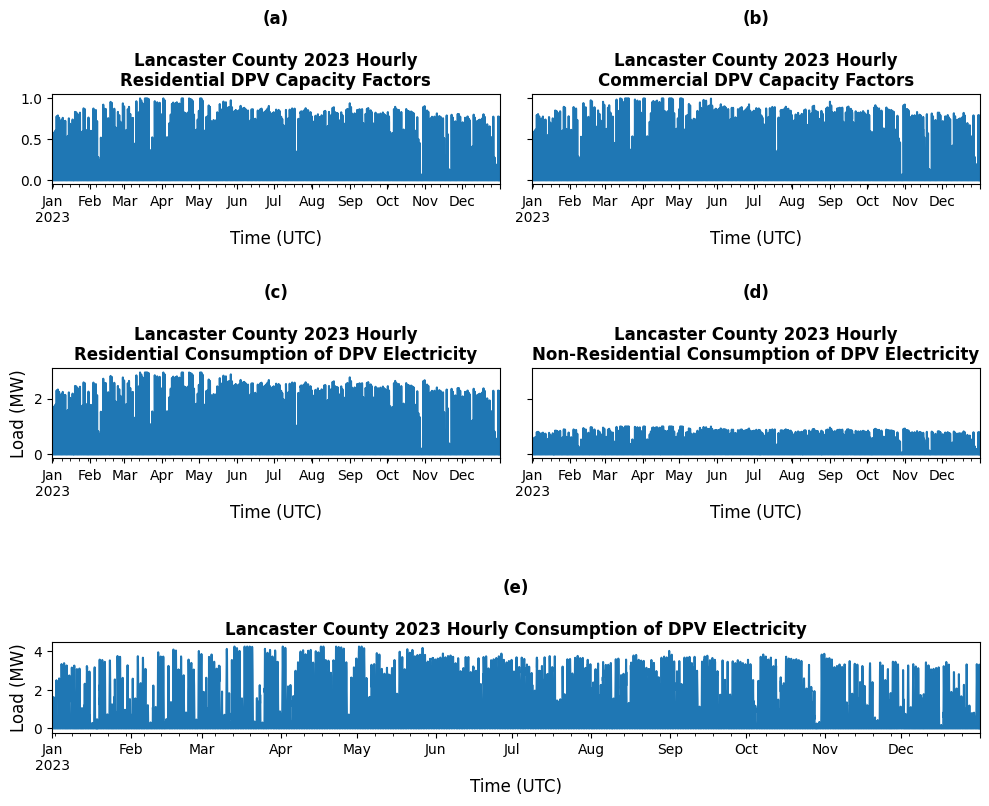

In [7]:
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(4, 2, height_ratios=[1, 1, 1, 0.7])

axes = []
for i in range(4):
    row = i // 2
    col = i % 2
    if col == 1:
        ax = fig.add_subplot(gs[row, col], sharey=axes[i-1])
    else:
        ax = fig.add_subplot(gs[row, col])
    axes.append(ax)

# Sixth plot spans the entire bottom row
ax5 = fig.add_subplot(gs[2, :])
axes.append(ax5)

ax_ = axes[0]
residential.plot(ax=ax_, legend=False)
ax_.set_title('(a)\n\nLancaster County 2023 Hourly\nResidential DPV Capacity Factors', fontweight='bold')
ax_.set_xlabel('Time (UTC)', fontsize=12)

ax_ = axes[1]
non_residential.plot(ax=ax_, legend=False)
ax_.set_title('(b)\n\nLancaster County 2023 Hourly\nCommercial DPV Capacity Factors', fontweight='bold')
ax_.set_xlabel('Time (UTC)', fontsize=12)

ax_ = axes[2]
residential_scaled.plot(ax=ax_, legend=False)
ax_.set_title('\n(c)\n\nLancaster County 2023 Hourly\nResidential Consumption of DPV Electricity', fontweight='bold')
ax_.set_xlabel('Time (UTC)', fontsize=12)
ax_.set_ylabel('Load (MW)', fontsize=12)

ax_ = axes[3]
non_residential.plot(ax=ax_, legend=False)
ax_.set_title('\n(d)\n\nLancaster County 2023 Hourly\nNon-Residential Consumption of DPV Electricity', fontweight='bold')
ax_.set_xlabel('Time (UTC)', fontsize=12)
ax_.set_ylabel('Load (MW)', fontsize=12)

ax_ = axes[4]
dpv_profile.plot(ax=ax_, legend=False)
ax_.set_title('(e)\n\nLancaster County 2023 Hourly Consumption of DPV Electricity', fontweight='bold')
ax_.set_xlabel('Time (UTC)', fontsize=12)
ax_.set_ylabel('Load (MW)', fontsize=12)

plt.tight_layout()
# plt.show()
plt.savefig('lancaster_county_dpv_profiles.png', dpi=300, bbox_inches='tight')

In [40]:
county_profile = rsdu_profile['value'] + dpv_profile.tz_localize(None)

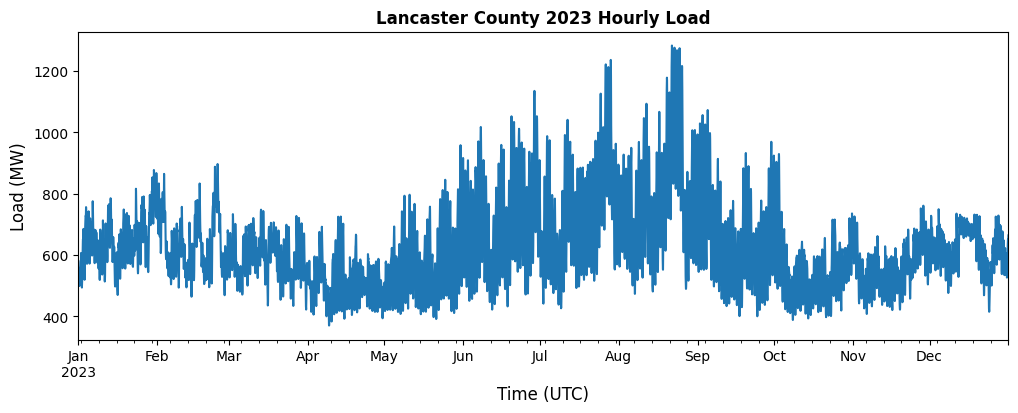

In [45]:
fig, ax = plt.subplots(figsize=(12, 4))

county_profile.loc[county_profile.index.year == 2023].plot(ax=ax, legend=False)
ax.set_title('Lancaster County 2023 Hourly Load', fontweight='bold')
ax.set_xlabel('Time (UTC)', fontsize=12)
ax.set_ylabel('Load (MW)', fontsize=12)

# plt.show()
plt.savefig('lancaster_county_load.png', dpi=300, bbox_inches='tight')